In [94]:
import pandas as pd
import numpy as np
import fastf1
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

Driver = [
    #McLaren
    "NOR",               #Lando Norris 🇬🇧
    "PIA",               #Oscar Piastri 🇦🇺
    #Red Bull Racing
    "VER",               #Max Verstappen 🇳🇱
    "HAD",               #Isack Hadjar 🇫🇷
    #Ferrari
    "LEC",               #Charles Leclerc 🇲🇨
    "HAM",               #Lewis Hamilton 🇬🇧
    #Mercedes
    "RUS",               #Geaorge Russell 🇬🇧
    "ANT",               #Andrea Kimi Antonelli 🇮🇹
    #Aston Martin Aramco
    "ALO",               #Fernando Alonso 🇪🇸
    "STR",               #Lance Stroll 🇨🇦
    #Williams
    "ALB",               #Alexander Albon 🇹🇭
    "SAI",               #Carlos Sainz Jr. 🇪🇸
    #Haas
    "OCO",               #Esteban Ocon 🇫🇷
    "BEA",               #Oliver Bearman 🇬🇧
    #Alpine
    "GAS",               #Piette Gasly 🇫🇷
    "COL",               #Franco Colapinto 🇦🇷
    #Audi
    "HUL",               #Nico Hulkenberg 🇩🇪
    "BOR",               #Gabriel Bortoleto 🇧🇷
    #Cadillac
    "PER",               #Sergio Perez 🇲🇽
    "BOT",               #Valtteri Bottas 🇫🇮
    #Racing Bulls
    "LAW",               #Liam Lawson 🇳🇿
    "LIN"                #Arvid Lindblad 🇬🇧

]

In [19]:
driver_to_team = {
    "NOR":"McLaren",
    "PIA":"McLaren",

    "VER":"Red Bull",
    "HAD":"Red Bull",

    "LEC":"Ferrari",
    "HAM":"Ferrari",

    "RUS":"Mercedes",
    "ANT":"Mercedes",

    "ALO":"Aston Martin",
    "STR":"Aston Martin",

    "ALB":"Williams",
    "SAI":"Williams",

    "OCO":"Haas",
    "BEA":"Haas",

    "GAS":"Alpine",
    "COL":"Alpine",

    "HUL":"Audi",
    "BOR":"Audi",

    "PER":"Cardillac",
    "BOT":"Cardillac",
    
    "LAW":"Racing Bulls",
    "LIN":"Racing Bulls"  
}

In [36]:
result_2023 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        9162.072,                 #NOR
        9163.753,                 #PIA
        #Red Bull Racing
        9158.371,                 #VER
        "NP",                 #HAD
        #Ferrari
        "DNF",                 #LEC
        9158.550,                 #HAM
        #Mercedes
        "DNF",                 #RUS
        "NP",                 #ANT
        #Aston Martin Aramco
        9159.140,                 #ALO
        9161.453,                 #STR
        #Williams
        "DNF",                 #ALB
        9164.965,                 #SAI
        #Haas
        "DNF",                 #OCO
        "NP",                 #BEA
        #Alpine
        "DNF",                 #GAS
        "NP",                 #COL
        #Audi
        9163.310,                 #HUL
        "NP",                 #BOR
        #Cadillac
        9161.691,                 #PER
        9164.884,                 #BOT
        #Racing Bulls
        "NP",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

In [37]:
result_2024 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        4832.747,                 #NOR
        4862.613,                 #PIA
        #Red Bull Racing
        "DNF",                 #VER
        "NP",                 #HAD
        #Ferrari
        4829.209,                 #LEC
        "DNF",                 #HAM
        #Mercedes
        "DNF",                 #RUS
        "NP",                 #ANT
        #Aston Martin Aramco
        4927.835,                 #ALO
        4920.065,                 #STR
        #Williams
        5014.396,                 #ALB
        4826.843,                 #SAI
        #Haas
        5014.396,                 #OCO
        "NP",                 #BEA
        #Alpine
        5014.396,                 #GAS
        "NP",                 #COL
        #Audi
        4931.396,                 #HUL
        "NP",                 #BOR
        #Cadillac
        4883.152,                 #PER
        5014.396,                 #BOT
        #Racing Bulls
        "NP",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

In [58]:
result_2025 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        6126.304,                 #NOR
        6146.751,                 #PIA
        #Red Bull Racing
        6127.199,                 #VER
        "DNF",                 #HAD
        #Ferrari
        6146.130,                 #LEC
        6148.777,                 #HAM
        #Mercedes
        6134.785,                 #RUS
        6136.439,                 #ANT
        #Aston Martin Aramco
        "DNF",                 #ALO
        6143.717,                 #STR
        #Williams
        6139.077,                 #ALB
        "DNF",                 #SAI
        #Haas
        6159.456,                 #OCO
        6166.655,                 #BEA
        #Alpine
        6152.806,                 #GAS
        "NP",                 #COL
        #Audi
        6144.727,                 #HUL
        "DNF",                 #BOR
        #Cadillac
        "NP",                 #PER
        "NP",                 #BOT
        #Racing Bulls
        "DNF",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

In [41]:
result_2025

,Driver,RaceTime (s)
0,NOR,6126.304
1,PIA,6146.751
2,VER,6127.199
3,HAD,DNF
4,LEC,6146.13
5,HAM,6148.777
6,RUS,6134.785
7,ANT,6136.439
8,ALO,DNF
9,STR,6143.717


In [22]:
qualifying_data_2025 = fastf1.get_session(2025,'Australia','Q')
qualifying_data_2025.load()

Quali_2025 = qualifying_data_2025.laps.pick_quicklaps()
Quali = Quali_2025.groupby("Driver")["LapTime"].min().dt.total_seconds()

qualifying_2025 = Quali.reset_index()
qualifying_2025.columns = ["Driver","QualifyingTime (s)"]

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '1', '63', '22', '23', '16', '44', '10', '55', '6', '14', '18', '7', '5', '12', '27', '30', '31', '87']


In [23]:
qualifying_2025

,Driver,QualifyingTime (s)
0,ALB,75.737
1,ALO,76.288
2,ANT,76.525
3,BOR,76.516
4,DOO,76.315
5,GAS,75.980
6,HAD,76.175
7,HAM,75.919
8,HUL,76.579
9,LAW,77.094


In [7]:
practices = {}
pbest_laps = {}

for i in range(1, 4):
    practices[i] = fastf1.get_session(2025, 'Australia', f'FP{i}')
    practices[i].load()

    pbest_laps[i] = (
        practices[i]
        .laps
        .pick_quicklaps()
        .groupby("Driver")["LapTime"]
        .min()
        .dt.total_seconds()
        .rename(f"FP{i}")
    )

practice_2025 = pd.concat(
    [pbest_laps[1], pbest_laps[2], pbest_laps[3]],
    axis=1
)

practice_2025["BestPracticeTime"] = practice_2025.min(axis=1)

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

In [9]:
practice_2025.reset_index(inplace=True)

In [10]:
practice_2025

,Driver,FP1,FP2,FP3,BestPracticeTime
0,ALB,77.713,77.302,76.258,76.258
1,ALO,77.736,77.330,77.270,77.270
2,ANT,78.390,77.634,76.206,76.206
3,BEA,79.312,NaN,NaN,79.312
4,BOR,78.438,77.847,76.707,76.707
5,DOO,78.232,77.394,76.993,76.993
6,GAS,78.505,77.493,76.719,76.719
7,HAD,77.847,77.019,76.732,76.732
8,HAM,78.071,76.859,76.378,76.378
9,HUL,78.586,77.161,77.146,77.146


In [15]:
team_points_2025 = {
    "McLaren":27,
    "Mercedes":27,
    "Red Bull":18,
    "Williams":10,
    "Ferrari":5,
    "Haas":00,
    "Aston Martin":8,
    "Racing Bulls":00,
    "Alpine":00,
    "Audi":00,
    "Cardillac":00
}

In [16]:
from sklearn.preprocessing import MinMaxScaler

teams_2025 = list(team_points_2025.keys())
points_2025 = np.array(list(team_points_2025.values())).reshape(-1,1)

scaler = MinMaxScaler()
scaled_points_2025 = scaler.fit_transform(points_2025)

team_performance_score_2025 = dict(zip(teams_2025, scaled_points_2025.flatten()))

In [17]:
team_performance_score_2025

{'McLaren': np.float64(1.0),
 'Mercedes': np.float64(1.0),
 'Red Bull': np.float64(0.6666666666666666),
 'Williams': np.float64(0.37037037037037035),
 'Ferrari': np.float64(0.18518518518518517),
 'Haas': np.float64(0.0),
 'Aston Martin': np.float64(0.2962962962962963),
 'Racing Bulls': np.float64(0.0),
 'Alpine': np.float64(0.0),
 'Audi': np.float64(0.0),
 'Cardillac': np.float64(0.0)}

In [24]:
qualifying_2025["Team"] = qualifying_2025["Driver"].map(driver_to_team)
qualifying_2025["TeamPerformanceScore"] = qualifying_2025["Team"].map(team_performance_score_2025)

In [25]:
qualifying_2025

,Driver,QualifyingTime (s),Team,TeamPerformanceScore
0,ALB,75.737,Williams,0.370370
1,ALO,76.288,Aston Martin,0.296296
2,ANT,76.525,Mercedes,1.000000
3,BOR,76.516,Audi,0.000000
4,DOO,76.315,NaN,NaN
5,GAS,75.980,Alpine,0.000000
6,HAD,76.175,Red Bull,0.666667
7,HAM,75.919,Ferrari,0.185185
8,HUL,76.579,Audi,0.000000
9,LAW,77.094,Racing Bulls,0.000000


In [59]:
result_2025["Team"] = result_2025["Driver"].map(driver_to_team)

In [60]:
result_2025

,Driver,RaceTime (s),Team
0,NOR,6126.304,McLaren
1,PIA,6146.751,McLaren
2,VER,6127.199,Red Bull
3,HAD,DNF,Red Bull
4,LEC,6146.13,Ferrari
5,HAM,6148.777,Ferrari
6,RUS,6134.785,Mercedes
7,ANT,6136.439,Mercedes
8,ALO,DNF,Aston Martin
9,STR,6143.717,Aston Martin


In [61]:
qualifying_2025.set_index("Driver",inplace=True)
practice_2025.set_index("Driver",inplace=True)
result_2023.set_index("Driver",inplace=True)
result_2024.set_index("Driver",inplace=True)
result_2025.set_index("Driver",inplace=True)

result_2025['CleanAirPace (s)'] = practice_2025['BestPracticeTime']
result_2025['Result_2023 (s)'] = result_2023['RaceTime (s)']
result_2025['Result_2024 (s)'] = result_2024['RaceTime (s)']
result_2025['Result_2025 (s)'] = result_2025['RaceTime (s)']
result_2025[['QualifyingTime (s)','TeamPerformanceScore']] = qualifying_2025[['QualifyingTime (s)','TeamPerformanceScore']]

qualifying_2025.reset_index(inplace=True)
practice_2025.reset_index(inplace=True)
result_2023.reset_index(inplace=True)
result_2024.reset_index(inplace=True)
result_2025.reset_index(inplace=True)

In [62]:
result_2025.drop('RaceTime (s)',axis=1,inplace=True)

In [63]:
result_2025['QualifyingTime_2025 (s)'] = result_2025['QualifyingTime (s)']

In [64]:
result_2025.drop('QualifyingTime (s)',axis=1,inplace=True)

In [65]:
result_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180
2,VER,Red Bull,76.002,9158.371,DNF,6127.199,0.666667,75.481
3,HAD,Red Bull,76.732,NP,NP,DNF,0.666667,76.175
4,LEC,Ferrari,76.188,DNF,4829.209,6146.13,0.185185,75.755
5,HAM,Ferrari,76.378,9158.55,DNF,6148.777,0.185185,75.919
6,RUS,Mercedes,75.960,DNF,DNF,6134.785,1.000000,75.546
7,ANT,Mercedes,76.206,NP,NP,6136.439,1.000000,76.525
8,ALO,Aston Martin,77.270,9159.14,4927.835,DNF,0.296296,76.288
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369


In [53]:
final_2025 = result_2025.copy()

In [67]:
final_2025 = final_2025[final_2025["Result_2025 (s)"]!='NP']

In [69]:
final_2025  = final_2025.reset_index(drop=True)

In [70]:
final_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096
1,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180
2,VER,76.002,9158.371,DNF,6127.199,Red Bull,0.666667,75.481
3,HAD,76.732,NP,NP,DNF,Red Bull,0.666667,76.175
4,LEC,76.188,DNF,4829.209,6146.13,Ferrari,0.185185,75.755
5,HAM,76.378,9158.55,DNF,6148.777,Ferrari,0.185185,75.919
6,RUS,75.960,DNF,DNF,6134.785,Mercedes,1.000000,75.546
7,ANT,76.206,NP,NP,6136.439,Mercedes,1.000000,76.525
8,ALO,77.270,9159.14,4927.835,DNF,Aston Martin,0.296296,76.288
9,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369


In [78]:
final_2025 = final_2025[final_2025["Team"].notna()]
final_2025 = final_2025.reset_index(drop=True)

In [79]:
final_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096
1,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180
2,VER,76.002,9158.371,DNF,6127.199,Red Bull,0.666667,75.481
3,HAD,76.732,NP,NP,DNF,Red Bull,0.666667,76.175
4,LEC,76.188,DNF,4829.209,6146.13,Ferrari,0.185185,75.755
5,HAM,76.378,9158.55,DNF,6148.777,Ferrari,0.185185,75.919
6,RUS,75.960,DNF,DNF,6134.785,Mercedes,1.000000,75.546
7,ANT,76.206,NP,NP,6136.439,Mercedes,1.000000,76.525
8,ALO,77.270,9159.14,4927.835,DNF,Aston Martin,0.296296,76.288
9,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369


In [80]:
final_2025["DNF_2025"] = (final_2025["Result_2025 (s)"]== "DNF").astype(int)
final_2025["NP_2025"] = (final_2025["Result_2025 (s)"]== "NP").astype(int)

final_2025["DNF_2024"] = (final_2025["Result_2024 (s)"]== "DNF").astype(int)
final_2025["NP_2024"] = (final_2025["Result_2024 (s)"]== "NP").astype(int)

final_2025["DNF_2023"] = (final_2025["Result_2023 (s)"]== "DNF").astype(int)
final_2025["NP_2023"] = (final_2025["Result_2023 (s)"]== "NP").astype(int)

In [81]:
final_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023
0,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096,0,0,0,0,0,0
1,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180,0,0,0,0,0,0
2,VER,76.002,9158.371,DNF,6127.199,Red Bull,0.666667,75.481,0,0,1,0,0,0
3,HAD,76.732,NP,NP,DNF,Red Bull,0.666667,76.175,1,0,0,1,0,1
4,LEC,76.188,DNF,4829.209,6146.13,Ferrari,0.185185,75.755,0,0,0,0,1,0
5,HAM,76.378,9158.55,DNF,6148.777,Ferrari,0.185185,75.919,0,0,1,0,0,0
6,RUS,75.960,DNF,DNF,6134.785,Mercedes,1.000000,75.546,0,0,1,0,1,0
7,ANT,76.206,NP,NP,6136.439,Mercedes,1.000000,76.525,0,0,0,1,0,1
8,ALO,77.270,9159.14,4927.835,DNF,Aston Martin,0.296296,76.288,1,0,0,0,0,0
9,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369,0,0,0,0,0,0


In [82]:
final_2025['Result_2025 (s)'] = pd.to_numeric(final_2025["Result_2025 (s)"],errors = "coerce")
final_2025['Result_2024 (s)'] = pd.to_numeric(final_2025["Result_2024 (s)"],errors = "coerce")
final_2025['Result_2023 (s)'] = pd.to_numeric(final_2025["Result_2023 (s)"],errors = "coerce")

In [83]:
final_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023
0,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096,0,0,0,0,0,0
1,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180,0,0,0,0,0,0
2,VER,76.002,9158.371,NaN,6127.199,Red Bull,0.666667,75.481,0,0,1,0,0,0
3,HAD,76.732,NaN,NaN,NaN,Red Bull,0.666667,76.175,1,0,0,1,0,1
4,LEC,76.188,NaN,4829.209,6146.130,Ferrari,0.185185,75.755,0,0,0,0,1,0
5,HAM,76.378,9158.550,NaN,6148.777,Ferrari,0.185185,75.919,0,0,1,0,0,0
6,RUS,75.960,NaN,NaN,6134.785,Mercedes,1.000000,75.546,0,0,1,0,1,0
7,ANT,76.206,NaN,NaN,6136.439,Mercedes,1.000000,76.525,0,0,0,1,0,1
8,ALO,77.270,9159.140,4927.835,NaN,Aston Martin,0.296296,76.288,1,0,0,0,0,0
9,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369,0,0,0,0,0,0


In [85]:
final_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Driver                   17 non-null     object 
 1   CleanAirPace (s)         17 non-null     float64
 2   Result_2023 (s)          8 non-null      float64
 3   Result_2024 (s)          10 non-null     float64
 4   Result_2025 (s)          12 non-null     float64
 5   Team                     17 non-null     object 
 6   TeamPerformanceScore     17 non-null     float64
 7   QualifyingTime_2025 (s)  17 non-null     float64
 8   DNF_2025                 17 non-null     int64  
 9   NP_2025                  17 non-null     int64  
 10  DNF_2024                 17 non-null     int64  
 11  NP_2024                  17 non-null     int64  
 12  DNF_2023                 17 non-null     int64  
 13  NP_2023                  17 non-null     int64  
dtypes: float64(6), int64(6), obj

In [113]:
X = final_2025[["CleanAirPace (s)","Result_2023 (s)","Result_2024 (s)",
"TeamPerformanceScore","QualifyingTime_2025 (s)","DNF_2024","DNF_2023","NP_2024","NP_2023"]]

y = final_2025[['Result_2025 (s)']]

In [114]:
imputer = SimpleImputer(strategy = "median")

In [115]:
X_imputed = imputer.fit_transform(X)

In [116]:
y_imputed = imputer.fit_transform(y)

In [117]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CleanAirPace (s)         17 non-null     float64
 1   Result_2023 (s)          8 non-null      float64
 2   Result_2024 (s)          10 non-null     float64
 3   TeamPerformanceScore     17 non-null     float64
 4   QualifyingTime_2025 (s)  17 non-null     float64
 5   DNF_2024                 17 non-null     int64  
 6   DNF_2023                 17 non-null     int64  
 7   NP_2024                  17 non-null     int64  
 8   NP_2023                  17 non-null     int64  
dtypes: float64(5), int64(4)
memory usage: 1.3 KB


In [118]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y_imputed, test_size = 0.2, random_state = 42)

In [119]:
model = XGBRegressor()

In [129]:
parameter ={
    'n_estimators': [100,200,300,400,500,600],
    'learning_rate': [.4,.5,.6,.7,.8,.9],
    'max_depth' :[1,2,3,4,5,6],
    'random_state':[42]
}

In [130]:
regcv = GridSearchCV(model, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')

In [131]:
regcv.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.4, 0.5, ...], 'max_depth': [1, 2, ...], 'n_estimators': [100, 200, ...], 'random_state': [42]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [132]:
y_pred = regcv.predict(X_test)

In [133]:
print(mean_absolute_error(y_pred,y_test))

8.064014648437478


In [134]:
final_2025 ['PredictedTime_2025 (s)'] = regcv.predict(X_imputed)


In [135]:
final_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2025 (s)
0,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096,0,0,0,0,0,0,6139.501953
1,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180,0,0,0,0,0,0,6135.908691
2,VER,76.002,9158.371,NaN,6127.199,Red Bull,0.666667,75.481,0,0,1,0,0,0,6127.199219
3,HAD,76.732,NaN,NaN,NaN,Red Bull,0.666667,76.175,1,0,0,1,0,1,6144.220703
4,LEC,76.188,NaN,4829.209,6146.130,Ferrari,0.185185,75.755,0,0,0,0,1,0,6146.128906
5,HAM,76.378,9158.550,NaN,6148.777,Ferrari,0.185185,75.919,0,0,1,0,0,0,6140.668945
6,RUS,75.960,NaN,NaN,6134.785,Mercedes,1.000000,75.546,0,0,1,0,1,0,6134.786133
7,ANT,76.206,NaN,NaN,6136.439,Mercedes,1.000000,76.525,0,0,0,1,0,1,6136.439453
8,ALO,77.270,9159.140,4927.835,NaN,Aston Martin,0.296296,76.288,1,0,0,0,0,0,6144.222168
9,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369,0,0,0,0,0,0,6143.717285


In [137]:
final_results_2025 = final_2025.sort_values(by=["PredictedTime_2025 (s)", "QualifyingTime_2025 (s)"]).reset_index(drop = True)
final_results_2025

,Driver,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),Team,TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2025 (s)
0,VER,76.002,9158.371,NaN,6127.199,Red Bull,0.666667,75.481,0,0,1,0,0,0,6127.199219
1,RUS,75.960,NaN,NaN,6134.785,Mercedes,1.000000,75.546,0,0,1,0,1,0,6134.786133
2,PIA,75.921,9163.753,4862.613,6146.751,McLaren,1.000000,75.180,0,0,0,0,0,0,6135.908691
3,ANT,76.206,NaN,NaN,6136.439,Mercedes,1.000000,76.525,0,0,0,1,0,1,6136.439453
4,ALB,76.258,NaN,5014.396,6139.077,Williams,0.370370,75.737,0,0,0,0,1,0,6139.077148
5,NOR,76.580,9162.072,4832.747,6126.304,McLaren,1.000000,75.096,0,0,0,0,0,0,6139.501953
6,HAM,76.378,9158.550,NaN,6148.777,Ferrari,0.185185,75.919,0,0,1,0,0,0,6140.668945
7,STR,76.948,9161.453,4920.065,6143.717,Aston Martin,0.296296,76.369,0,0,0,0,0,0,6143.717285
8,BOR,76.707,NaN,NaN,NaN,Audi,0.000000,76.516,1,0,0,1,0,1,6144.114258
9,HAD,76.732,NaN,NaN,NaN,Red Bull,0.666667,76.175,1,0,0,1,0,1,6144.220703


In [142]:
podium = final_results_2025.loc[:,["Driver","PredictedTime_2025 (s)"]]
print("\n Predicted in the Top 3")
print(f"P1: {podium.iloc[0]['Driver']}")
print(f"P2: {podium.iloc[1]['Driver']}")
print(f"P3: {podium.iloc[2]['Driver']}")

print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")


 Predicted in the Top 3
P1: VER
P2: RUS
P3: PIA
Model Error (MAE): 8.06 seconds


In [139]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

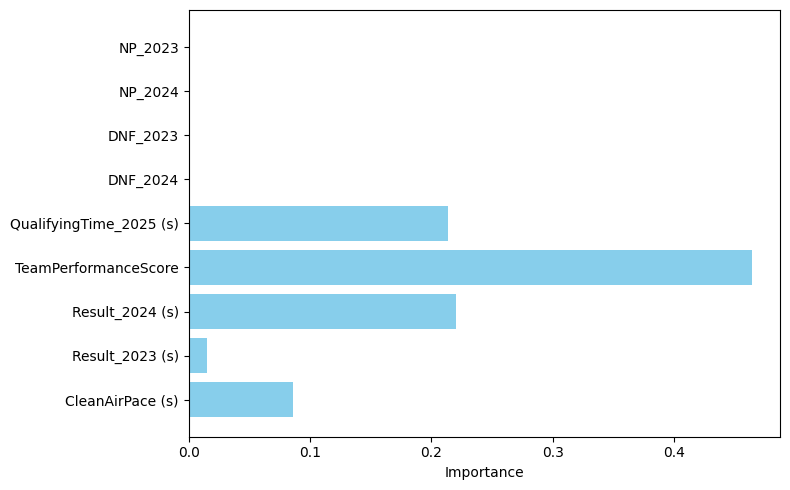

In [140]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()